In [1]:
from utils import SphericalWaveAnalytic, ExtractResultOnDefinedAxis, wavenumber_spectrum
import sys
sys.path.append("../../../../../share/python/")
from postprocess_25d import PostProcessHarmonic25d
import numpy as np
import matplotlib.pyplot as plt

## Compare Wavenumber Spectrum at a given Coordinate (x,y)

In [40]:
freq = 100.1 # 100 Hz
pos = np.linspace(0,20,50) # 0 to 5 m in z direction
# file = 'AcousticHarmonic25D.h5ref'
file = 'results_hdf5/AcousticHarmonic25D.cfs'

PostProcessHarmonic25d(file_name=file, copy_file_name="AcousticHarmonic25D_postprocessed.cfs", pos_list=pos, create_copy=True)
shift_point_desired = [10.0,0]
z,coord,result = ExtractResultOnDefinedAxis(hdf_name='AcousticHarmonic25D_postprocessed.cfs',result='acouPressure', region="S_channel",step='all',multistep=2,dim='2.5d',axis='z',ShiftCoord=shift_point_desired)
shift_point_actual = coord[0,0:2]
print(shift_point_desired,shift_point_actual)
WaveNumFreqs,_,WaveNumSpectrumFEM = ExtractResultOnDefinedAxis(hdf_name=file,result='acouPressure', region="S_channel",step='all',multistep=1,dim='2.5d',axis='z',ShiftCoord=shift_point_desired, ExtractSpectrum = True)

# Create a dense curve for the "true" function plot
x_true_curve = np.linspace(0, freq+2+50, 10000)
y_true_curve = np.array([wavenumber_spectrum(ExcitationFreq=freq, freq = x, r = np.linalg.norm(shift_point_desired)) for x in x_true_curve])

[10.0, 0] [10.00416667  0.        ]


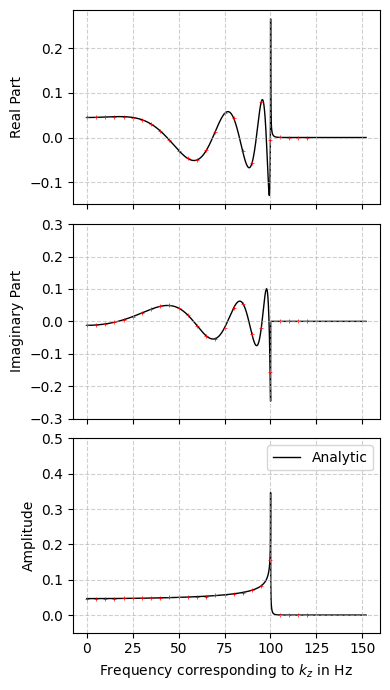

In [41]:
# --- 4. Final Plotting ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(4, 7), sharex=True)
#fig.suptitle(r"Wavenumber Spectrum $\tilde{p}$ at (x,y) = (%.2f,%.2f)" % (shift_point_actual[0],shift_point_actual[1]), fontsize=8)
LINEWIDTH = 1.0
MARKERSIZE = 0.5
# Real Part Subplot
ax1.plot(x_true_curve, y_true_curve.real, label='Analytic', color='black', linewidth = LINEWIDTH,zorder=1)
ax1.scatter(WaveNumFreqs, WaveNumSpectrumFEM.real / 4.0, s = 5,marker = "+",linewidth=0.5,color='red')
#ax1.set_ylim(-0.3,0.4)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.set_ylabel("Real Part")

# Imaginary Part Subplot
ax2.plot(x_true_curve, y_true_curve.imag, label='Analytic', color='black', linewidth = LINEWIDTH,zorder=1)
ax2.scatter(WaveNumFreqs, WaveNumSpectrumFEM.imag / 4.0, s = 5,marker = "+",linewidth=0.5,color='red')
#ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_ylim(-0.3,0.3)
ax2.set_ylabel("Imaginary Part")

ax3.plot(x_true_curve, np.abs(y_true_curve), label='Analytic', color='black', linewidth = LINEWIDTH,zorder=1)
ax3.scatter(WaveNumFreqs, np.abs(WaveNumSpectrumFEM / 4.0), s = 5,marker = "+",linewidth=0.5,color='red')
ax3.set_ylabel("Amplitude")
ax3.grid(True, linestyle='--', alpha=0.6)
ax3.set_ylim(-0.05,0.5)
ax3.legend()
ax3.set_xlabel(r"Frequency corresponding to $k_z$ in Hz")
#ax3.set_xlim(190,210)

plt.tight_layout()
plt.show()

## Compare Pressure Along x-Axis for z = 0 m

In [33]:
x,result_x = ExtractResultOnDefinedAxis(hdf_name='AcousticHarmonic25D_postprocessed.cfs',result='acouPressure', region="S_channel",step=1,multistep=2,dim='2.5d',axis='x')
_, result_x_analytic = SphericalWaveAnalytic(rhsValue=1,freq=freq, r=x, sphere='fourth')

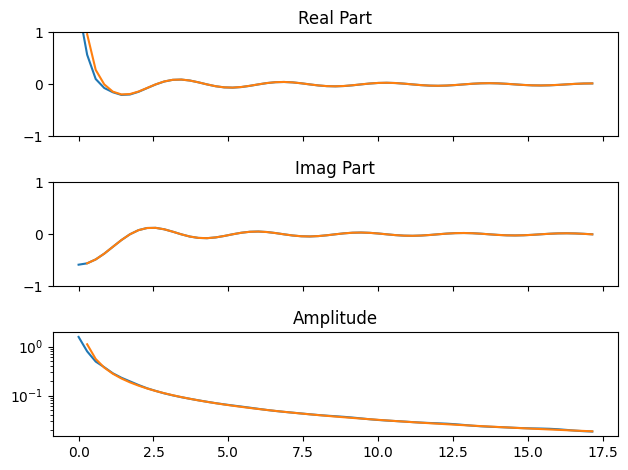

In [34]:
fig, ax = plt.subplots(nrows=3,ncols=1,sharex=True)

ax[0].plot(x,result_x.real)
ax[0].plot(x,result_x_analytic.real)
ax[0].set_ylim(-1,1)
ax[0].set_title("Real Part")
ax[1].plot(x,result_x.imag)
ax[1].plot(x,result_x_analytic.imag)
ax[1].set_ylim(-1,1)
ax[1].set_title("Imag Part")
ax[2].plot(x,np.abs(result_x),label='2.5D solution')
ax[2].plot(x,np.abs(result_x_analytic),label='analytic solution')
ax[2].set_yscale("log")
ax[2].set_title("Amplitude")
plt.tight_layout()
plt.show()

## Compare Pressure Along z-Axis for a given (x,y)

In [38]:
_, result_analytic = SphericalWaveAnalytic(rhsValue=1,freq=freq, r=coord, sphere='fourth')

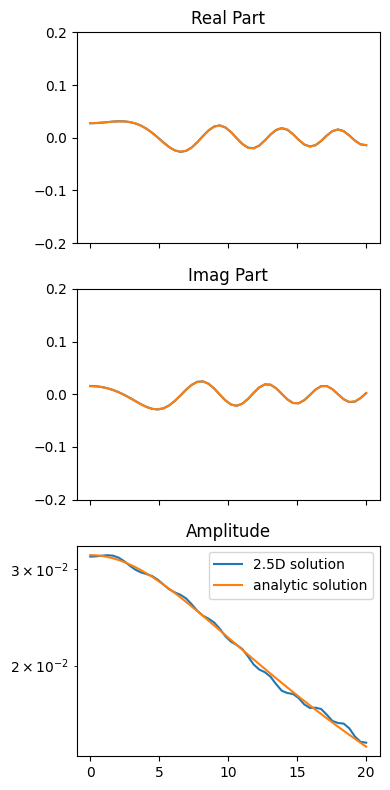

In [39]:
fig, ax = plt.subplots(nrows=3,ncols=1,sharex=True,figsize=(4,8))
ax[0].plot(z,result.real)
ax[0].plot(z,result_analytic.real)
ax[0].set_ylim(-0.2,0.2)
ax[0].set_title("Real Part")
ax[1].plot(z,result.imag)
ax[1].plot(z,result_analytic.imag)
ax[1].set_ylim(-0.2,0.2)
ax[1].set_title("Imag Part")
ax[2].plot(z,np.abs(result),label='2.5D solution')
ax[2].plot(z,np.abs(result_analytic),label='analytic solution')
#ax[2].set_yscale("log")
ax[2].set_title("Amplitude")
ax[2].legend()
ax[2].set_yscale("log")
plt.tight_layout()
plt.show()